# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 2. Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving winequality (1).csv to winequality (1).csv


In [ ]:
df = pd.read_csv("winequality (1).csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Shape

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1599, 12)


# 4. Check Missing Values

In [ ]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


# 5. Correlation Analysis

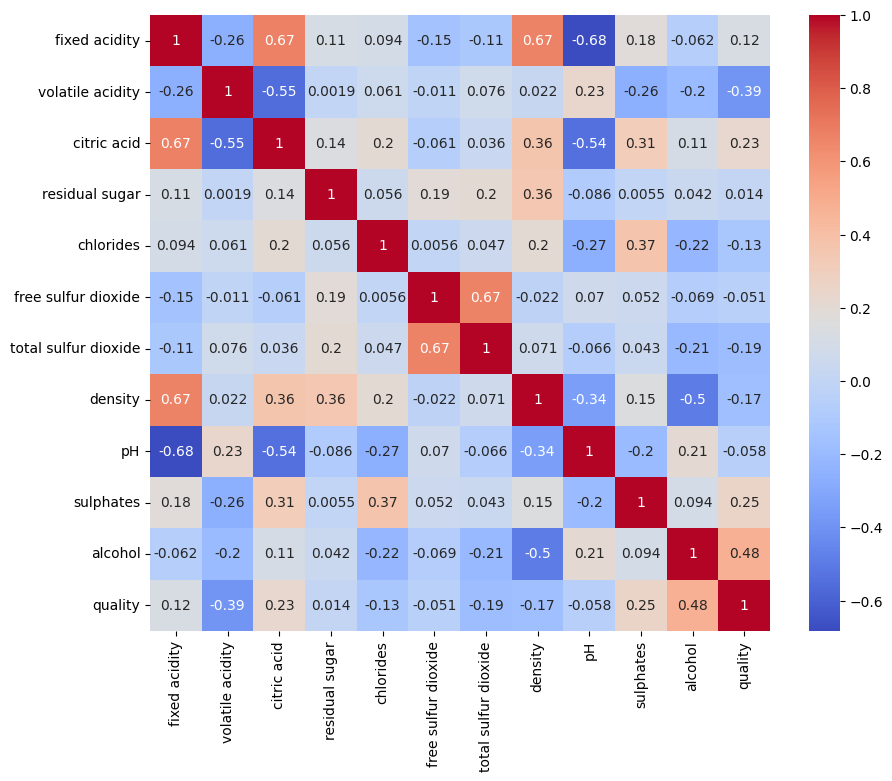

In [ ]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Correlation with Quality

In [ ]:
print(corr["quality"].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


## 6. Create Binary Target Variable

In [ ]:
df["quality_label"] = np.where(df["quality"] >= 7, 1, 0)

print(df["quality_label"].value_counts())

quality_label
0    1382
1     217
Name: count, dtype: int64


# 7. Separate Features and Target

In [ ]:
X = df.drop(["quality","quality_label"], axis=1)

y = df["quality_label"]

# 8. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 9. Logistic Regression WITHOUT Scaling

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

Evaluation

In [ ]:
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

Accuracy : 0.89375
Precision: 0.7368421052631579
Recall   : 0.32558139534883723
F1 Score : 0.45161290322580644
[[272   5]
 [ 29  14]]


# 10. Apply StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# 11. Logistic Regression WITH Scaling

In [ ]:
lr_scaled = LogisticRegression(max_iter=1000)

lr_scaled.fit(X_train_scaled,y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

Evaluation

In [ ]:
print("Accuracy :", accuracy_score(y_test,y_pred_scaled))
print("Precision:", precision_score(y_test,y_pred_scaled))
print("Recall   :", recall_score(y_test,y_pred_scaled))
print("F1 Score :", f1_score(y_test,y_pred_scaled))

print(confusion_matrix(y_test,y_pred_scaled))

Accuracy : 0.89375
Precision: 0.6956521739130435
Recall   : 0.37209302325581395
F1 Score : 0.48484848484848486
[[270   7]
 [ 27  16]]


# 12. Compare Before and After Scaling

In [ ]:
results = pd.DataFrame({
    "Model":["Logistic Regression (No Scaling)",
             "Logistic Regression (Scaled)"],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_scaled)
    ]
})

print(results)

                              Model  Accuracy
0  Logistic Regression (No Scaling)   0.89375
1      Logistic Regression (Scaled)   0.89375


## 13. Compare Multiple Models

Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled,y_train)

lr_pred = lr.predict(X_test_scaled)

KNN

In [ ]:
knn = KNeighborsClassifier()

knn.fit(X_train_scaled,y_train)

knn_pred = knn.predict(X_test_scaled)

Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

# 14. Model Comparison Table

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,dt_pred)
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression   0.89375
1                  KNN   0.89375
2        Decision Tree   0.90000


Best Model

In [ ]:
comparison.sort_values("Accuracy", ascending=False)

,Model,Accuracy
2,Decision Tree,0.90000
0,Logistic Regression,0.89375
1,KNN,0.89375


# 15. Hyperparameter Tuning

In [ ]:
param_grid = {

    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']

}

In [ ]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
0.8678645833333334


# 16. Evaluate Tuned Model

In [ ]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,best_pred))

print(classification_report(y_test,best_pred))

Accuracy: 0.91875
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       277
           1       0.73      0.63      0.68        43

    accuracy                           0.92       320
   macro avg       0.84      0.80      0.81       320
weighted avg       0.91      0.92      0.92       320



# 17. Feature Importance Analysis

In [ ]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": importance

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                 Feature  Importance
10               alcohol    0.383396
9              sulphates    0.169467
1       volatile acidity    0.106365
6   total sulfur dioxide    0.094420
5    free sulfur dioxide    0.072355
8                     pH    0.067397
3         residual sugar    0.067130
2            citric acid    0.024251
4              chlorides    0.015218
0          fixed acidity    0.000000
7                density    0.000000


# Visualization

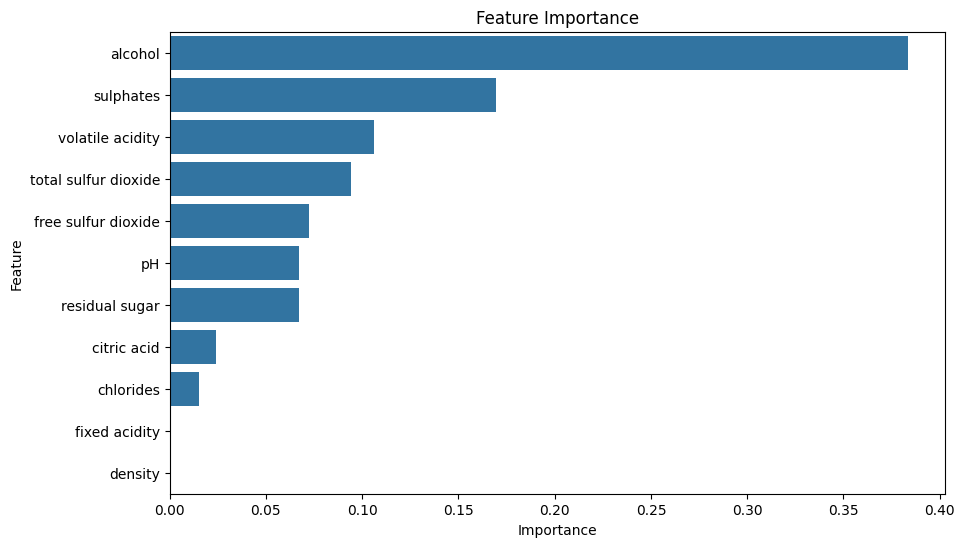

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()